In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import copy
import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys

In [2]:

config_bright_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(_surveys.config_survey_bright, max_mag=_surveys.max_mag[0]) 
config_grey_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(_surveys.config_survey_grey, max_mag=_surveys.max_mag[1])     
config_dark_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(_surveys.config_survey_dark, max_mag=_surveys.max_mag[2])   
max_mag=_surveys.max_mag

 We compute the survey completeness C(n) after n >= 1 passes
 After a maximum number of passes, the survey is said complete 
 We compute the survey completeness C(n) after n >= 1 passes
 After a maximum number of passes, the survey is said complete 
 We compute the survey completeness C(n) after n >= 1 passes
 After a maximum number of passes, the survey is said complete 


/global/u2/c/cpayerne/WP221_Target_selection/survey_design/_survey_design_telescope_metrics.py:43: RuntimeWarning: invalid value encountered in divide
  config_survey_update[tracer + '_' + 'spec_density']/config_survey_update[tracer + '_' + 'target_density'], f'',


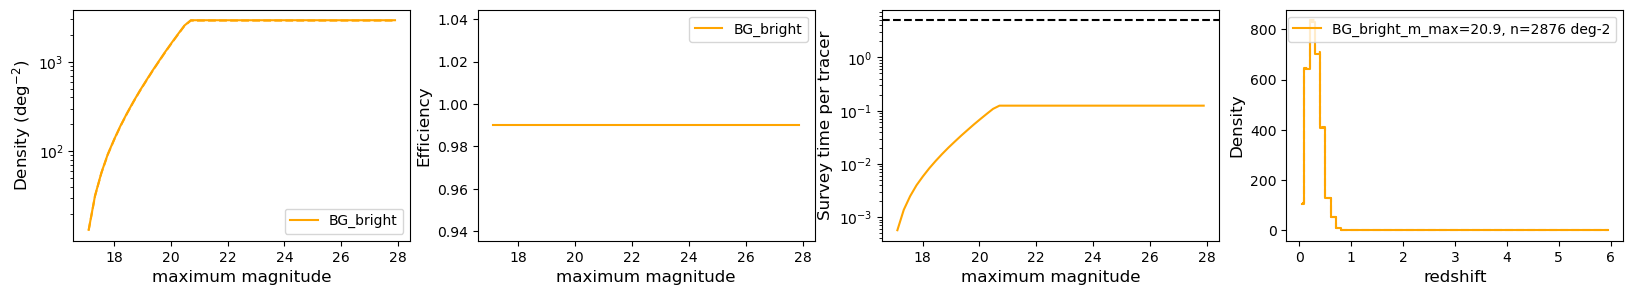

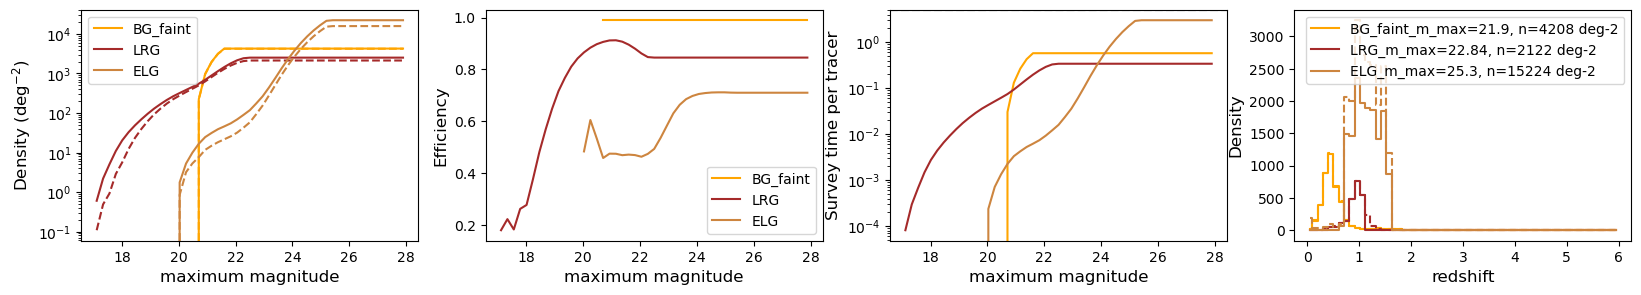

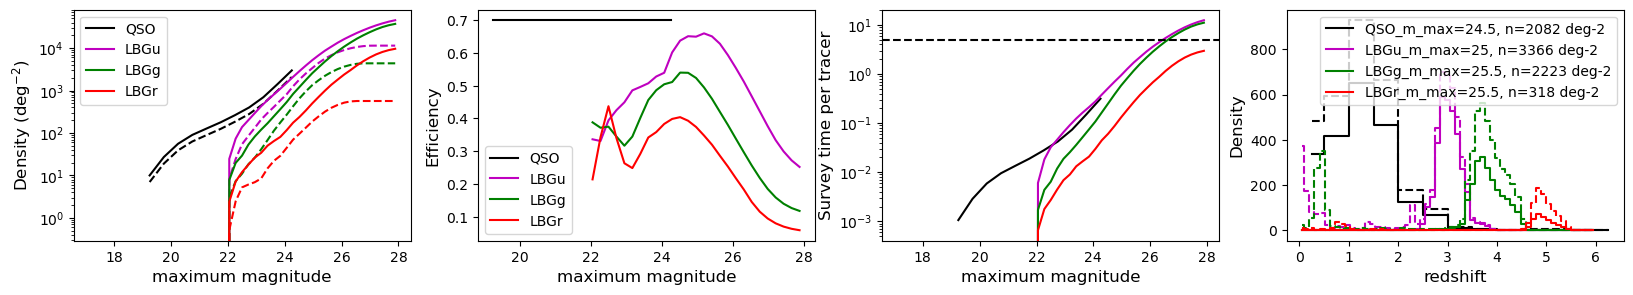

In [3]:

for i, c in enumerate([config_bright_update, config_grey_update,config_dark_update]):
    plt.figure(figsize=(20,3))
    _survey_design_telescope_metrics.plot_diagnostics(c, max_mag =  max_mag[i])

/tmp/ipykernel_1294498/1466463138.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


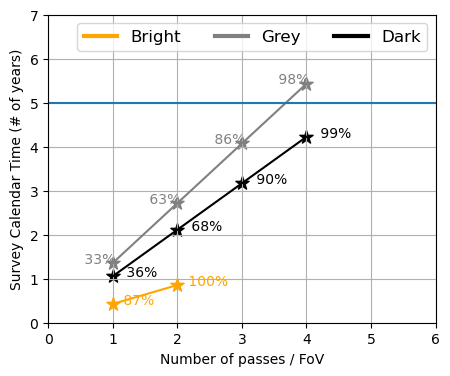

In [4]:
plt.figure(figsize=(5,4))
color = ['orange', 'gray', 'k']
shift = [0.1, -0.5, 0.15]
for i, config in enumerate([config_bright_update, config_grey_update, config_dark_update]):

    comp = config['total_survey_completeness']
    mask = comp <= 0.999
    plt.scatter(config['total_number_of_passes'][mask], config['total_survey_calendar_time'][mask], color = color[i],marker='*',s=100)
    plt.plot(config['total_number_of_passes'][mask], config['total_survey_calendar_time'][mask],color=color[i])
    for j, n in enumerate(config['total_number_of_passes'][mask]):
        plt.text(n+shift[i], config['total_survey_calendar_time'][j], f' {100*comp[j]:.0f}%', color = color[i],)
    plt.legend()
plt.xlabel('Number of passes / FoV')
plt.ylabel('Survey Calendar Time (# of years)')
for i, config in enumerate([config_bright_update, config_grey_update, config_dark_update]):
    plt.plot([], [], color = color[i], label = config['survey_type'], lw=3)
plt.ylim(0, 7)
plt.xlim(-0, 6)
plt.grid()
plt.axhline(5)
plt.legend(ncols=3, fontsize=12)